In [1]:

#%% Run to have everything 

import torch
from numpy import random
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath("../tgv_pycuda-master"))
sys.path.append(os.path.abspath("../tgv_odl_pghd/denoise"))
sys.path.append(os.path.abspath(".."))




from Algo_setuptorch import Params
#from Algo_setup_tomo import Params
from data.dataset import build_train_test_data
#from data.dataset_tomo import build_train_test_data

from algorithm.unrolled_model import UnrolledFBS
from training.train import train
from NN.plots import *
from NN.run import *


from denoise_pycuda import tgv_denoise

from pghd_denoising import pdhg






device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

params = Params()

TRAIN_SEEDS = list(range(50))  
TEST_SEEDS = list(range(50,60))


size = params.size
SHAPES = [
    (1, 1, size, size),
    (1, 2, size, size),
    (1, 2, size, size),
    (1, 4, size, size),
]
N_CH = sum(s[1] for s in SHAPES)
N_CH_primal = sum(s[1] for s in SHAPES[:2])
print("ok")

train_data, test_data = build_train_test_data(
    train_seeds=TRAIN_SEEDS,
    test_seeds=TEST_SEEDS,
    params=params,
    device=device,
)


initial_state, clean, functions = test_data[0]

Device: cuda
ok


In [2]:

model = UnrolledFBS(
    params=params,
    shapes=SHAPES,
    n_channels=N_CH_primal,
    T=10,
    alpha=0.99,
).to(device).float()

model.load_state_dict(torch.load("model_final_10.pt", map_location="cpu"))

model.eval()
 

UnrolledFBS(
  (dev_net): DeviationNet(
    (input_norm): InstanceNorm2d(21, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (body): Sequential(
      (0): ConvBlock(
        (conv): Conv2d(21, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      )
      (1): ConvBlock(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      )
    )
    (final): Conv2d(32, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

In [3]:
F_vals_0, res_0= run_zero(initial_state,functions, params, SHAPES, 500, device)
F_vals,res ,history= run_learned(model,initial_state,clean,functions,T_test=500,return_all=True)
import matplotlib.pyplot as plt

img = history["x"][-1][0]

# convertir proprement
img_np = img.detach().cpu().squeeze().numpy()

plt.imsave("final_image.png", img_np, cmap="gray")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

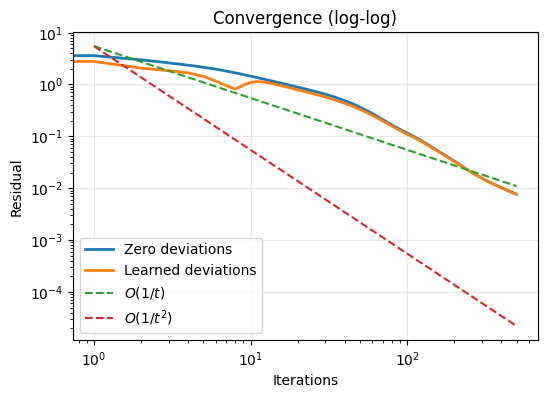

In [4]:

# Convertir en numpy si besoin
res_0 = np.array(res_0)
res = np.array(res)

# Axe des itérations 
iters = np.arange(1, len(res_0) + 1)

plt.figure(figsize=(6,4))

# Courbes principales

plt.loglog(res_0[1:], label='Zero deviations', linewidth=2)
plt.loglog(res[1:], label='Learned deviations', linewidth=2)
# Références théoriques
plt.loglog(iters, res_0[0]/iters, '--', label=r'$O(1/t)$')
plt.loglog(iters, res_0[0]/iters**2, '--', label=r'$O(1/t^2)$')

plt.xlabel('Iterations')
plt.ylabel('Residual')
plt.title('Convergence (log-log)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

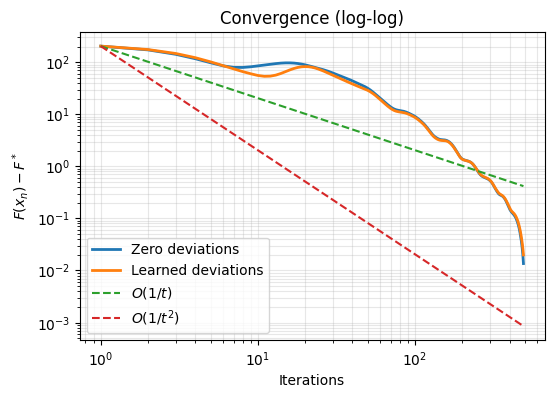

In [5]:
# convertir proprement
F_vals_0 = np.array([
    f.detach().cpu().item() if torch.is_tensor(f) else f
    for f in F_vals_0
])

F_vals = np.array([
    f.detach().cpu().item() if torch.is_tensor(f) else f
    for f in F_vals
])

# approx de F*
F_star = min(F_vals_0.min(), F_vals.min())

# gaps
gap_0 = F_vals_0 - F_star
gap   = F_vals   - F_star

# éviter log(0)
gap_0 = np.maximum(gap_0, 1e-16)
gap   = np.maximum(gap,   1e-16)

gap_0 = gap_0[:490]
gap   =gap[:490]


iters = np.arange(1, len(gap_0) + 1)

plt.figure(figsize=(6,4))

plt.loglog(iters, gap_0, label='Zero deviations', linewidth=2)
plt.loglog(iters, gap,   label='Learned deviations', linewidth=2)

# références
plt.loglog(iters, gap_0[0]/iters, '--', label=r'$O(1/t)$')
plt.loglog(iters, gap_0[0]/iters**2, '--', label=r'$O(1/t^2)$')

plt.xlabel('Iterations')
plt.ylabel(r'$F(x_n) - F^*$')
plt.title('Convergence (log-log)')
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.show()

In [6]:



x, F_vals = pdhg()

F_vals_learned,res_learned = run_learned(model,initial_state,clean,functions,T_test=500)

gaps = np.array(F_vals) - min(F_vals)
gaps_learned = np.array(F_vals_learned) - min(F_vals_learned)

gaps=gaps[:1000]
gaps_learned=gaps_learned[:1000]

iter = 0
Iter 1: F(x) = 94.792171
iter = 1
Iter 2: F(x) = 92.216682
iter = 2
Iter 3: F(x) = 88.766156
iter = 3
Iter 4: F(x) = 84.695411
iter = 4
Iter 5: F(x) = 80.228742
iter = 5
Iter 6: F(x) = 75.570244
iter = 6
Iter 7: F(x) = 70.897391
iter = 7
Iter 8: F(x) = 66.203726
iter = 8
Iter 9: F(x) = 61.493738
iter = 9
Iter 10: F(x) = 56.846498
iter = 10
Iter 11: F(x) = 52.311269
iter = 11
Iter 12: F(x) = 48.010126
iter = 12
Iter 13: F(x) = 44.069616
iter = 13
Iter 14: F(x) = 40.504616
iter = 14
Iter 15: F(x) = 37.320611
iter = 15
Iter 16: F(x) = 34.559214
iter = 16
Iter 17: F(x) = 32.266355
iter = 17
Iter 18: F(x) = 30.462528
iter = 18
Iter 19: F(x) = 29.128286
iter = 19
Iter 20: F(x) = 28.240776
iter = 20
Iter 21: F(x) = 27.768633
iter = 21
Iter 22: F(x) = 27.653490
iter = 22
Iter 23: F(x) = 27.838364
iter = 23
Iter 24: F(x) = 28.261680
iter = 24
Iter 25: F(x) = 28.881499
iter = 25
Iter 26: F(x) = 29.644671
iter = 26
Iter 27: F(x) = 30.497719
iter = 27
Iter 28: F(x) = 31.392485
iter = 28
I

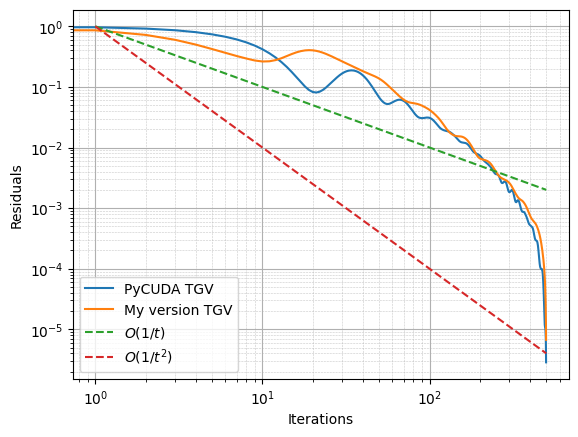

In [7]:

gaps = gaps[gaps > 1e-12]
gaps_learned = gaps_learned[gaps_learned > 1e-12]
gaps /= gaps[0]
gaps_learned /= gaps_learned[0]
N = min(len(gaps), len(gaps_learned))
t = np.arange(1, N + 1)

plt.loglog(gaps[:N], label="PyCUDA TGV")
plt.loglog(gaps_learned[:N], label="My version TGV")




ref1 = 1/ t         # O(1/t)
ref2 = 1 / (t**2)    # O(1/t^2)

plt.loglog(t, ref1, '--', label=r'$O(1/t)$')
plt.loglog(t, ref2, '--', label=r'$O(1/t^2)$') 

plt.xlabel("Iterations")
plt.ylabel("Residuals")
plt.legend()
plt.minorticks_on()  # active les sous-graduations
plt.grid(which='major', linestyle='-', linewidth=0.8)
plt.grid(which='minor', linestyle='--', linewidth=0.4, alpha=0.7)

plt.savefig("energy.pdf")
plt.show()  